# scikit-learn — synthetic datasets (`make_*`)

> 📘 **Instructor Curriculum** — M07 Machine Learning

**Status:** 🟡 Learning. This notebook **generates** data. No model is trained yet.

## What is a synthetic dataset?

A synthetic dataset is data that scikit-learn **invents** for you.

You describe the shape you want — how many rows, how many columns, how much
noise — and the library builds a table that matches. Nothing is downloaded.
Nothing is read from disk. The numbers come from a formula plus a random
number generator.

## Why do we need it?

You are learning algorithms, not data cleaning. A real CSV fights back: missing
values, text columns, wrong types, an unclear target. All of that hides the one
question you are actually asking — *does this algorithm work, and when does it
fail?*

| Reason | What it buys you |
|---|---|
| **You already know the answer** | You chose the slope, the number of clusters, the noise. So you can check whether the model found it. |
| **You control the difficulty** | Turn one knob and the problem gets harder. That is how you learn what breaks a model. |
| **It is reproducible** | `random_state=0` gives every reader the same rows, forever. |
| **It is instant** | No download, no licence, no privacy review, no NDA. |

**Engineering view.** This is a **test fixture generator**. It is the same idea
as a `TestDataBuilder` or a Faker factory in a Spring Boot test suite. You are
not testing the data. You are testing the code that consumes the data — and a
fixture you built yourself is the only one whose expected result you know.

## The family

Every generator returns the same two things: `X` (the inputs) and `y` (the
answer). Only the *shape* of the answer changes.

| Generator | `y` is | The picture it makes | Built to test |
|---|---|---|---|
| `make_regression` | a number | a noisy straight line | linear regression, MSE, R² |
| `make_classification` | a label | blobs at the corners of a cube | logistic regression, trees, feature selection |
| `make_blobs` | a cluster id | round, separated groups | KMeans, DBSCAN |
| `make_circles` | a label | a ring inside a ring | anything **non-linear** |
| `make_moons` | a label | two interlocking crescents | anything **non-linear** |

```text
                       what kind of answer do I want?
                                    │
             ┌──────────────────────┼──────────────────────┐
             │                      │                      │
        a number               a category            no answer at all
             │                      │                      │
     make_regression       make_classification         make_blobs
                                    │              (y is just a group id)
                          is a straight line
                            allowed to work?
                             │           │
                            yes          no
                             │           │
                    make_classification  make_circles / make_moons
```

Read the notebook in that order. Each section shows the call, every parameter,
and one chart of what the parameter actually changes.

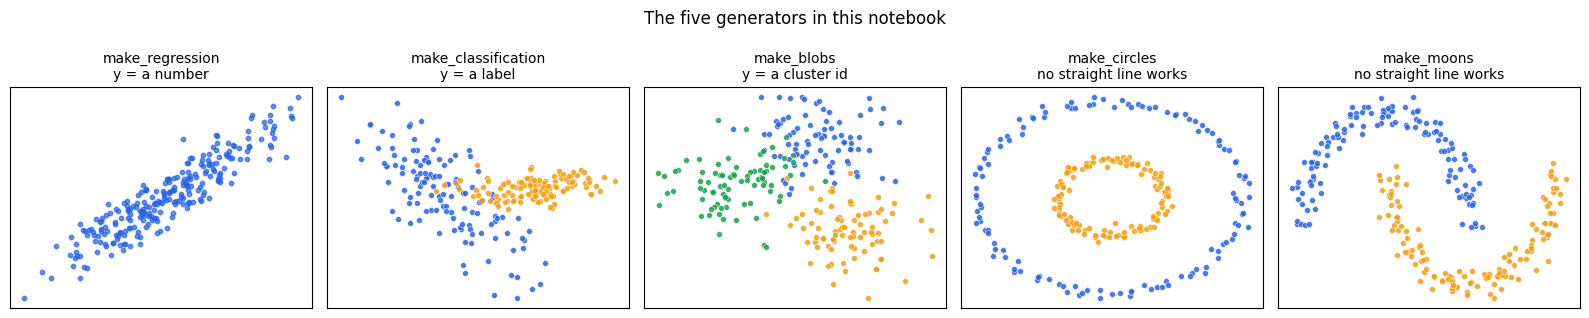

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import (make_regression, make_classification,
                              make_blobs, make_circles, make_moons)

# One colour per class label, reused by every chart in this notebook.
CLASS_COLOURS = ["#2563eb", "#f59e0b", "#16a34a", "#db2777"]


def scatter_classes(ax, X, y, cols=(0, 1), title="", size=18):
    """Scatter two columns of X, coloured by the label in y."""
    for label in np.unique(y):
        points = X[y == label]
        ax.scatter(points[:, cols[0]], points[:, cols[1]], s=size, alpha=0.85,
                   color=CLASS_COLOURS[label % len(CLASS_COLOURS)],
                   edgecolor="white", linewidth=0.4, label=f"class {label}")
    ax.set_title(title, fontsize=10)


# The whole family, side by side.
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))

gx, gy = make_regression(n_samples=250, n_features=1, noise=8, random_state=0)
axes[0].scatter(gx, gy, s=10, color="#2563eb", alpha=0.7)
axes[0].set_title("make_regression\ny = a number", fontsize=10)

cx, cy = make_classification(n_samples=250, n_features=2, n_informative=2,
                             n_redundant=0, n_clusters_per_class=1, random_state=4)
scatter_classes(axes[1], cx, cy, title="make_classification\ny = a label")

bx, by = make_blobs(n_samples=250, centers=3, n_features=2, random_state=0)
scatter_classes(axes[2], bx, by, title="make_blobs\ny = a cluster id")

rx, ry = make_circles(n_samples=250, noise=0.03, factor=0.4, random_state=1)
scatter_classes(axes[3], rx, ry, title="make_circles\nno straight line works")

mx, my = make_moons(n_samples=250, noise=0.08, random_state=10)
scatter_classes(axes[4], mx, my, title="make_moons\nno straight line works")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("The five generators in this notebook", fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

## 1 — `make_regression`: a straight line with noise on top

**Regression** means the answer is a **number** — a price, a temperature, a
salary. Not a category.

`make_regression` builds that kind of data from one formula:

```text
   y   =   X · coef   +   bias   +   noise
   │       │      │       │           └── random wobble, size set by you
   │       │      │       └── a constant shift (default 0)
   │       │      └── the slope(s) sklearn invents and keeps secret
   │       └── the input columns, drawn from a normal distribution
   └── the answer
```

Your call:

```python
x, y = make_regression(n_features=1, noise=5, n_samples=10000, random_state=0)
```

In plain English: *"Give me 10,000 rows and 1 input column. Add noise of size 5.
Do it the same way every time."*

### Every parameter

| Parameter | Default | What it does |
|---|---|---|
| `n_samples` | `100` | how many rows |
| `n_features` | `100` | how many input columns in total |
| `n_informative` | `10` | how many of those columns actually move `y`. The rest are decoration |
| `n_targets` | `1` | how many answer columns. Above 1, `y` becomes 2-D |
| `bias` | `0.0` | the intercept — the value of `y` when every input is 0 |
| `noise` | `0.0` | standard deviation of the wobble added to `y`. `0` gives a perfect line |
| `coef` | `False` | `True` also returns the true slopes, so you can grade a model |
| `shuffle` | `True` | shuffles both the rows and the column order |
| `effective_rank` | `None` | makes columns correlated with each other, the way real data is |
| `tail_strength` | `0.5` | only used together with `effective_rank` |
| `random_state` | `None` | the seed. Fix it, or the data changes on every run |

⚠️ **The default is 100 columns, not 1.** `n_features=100` with
`n_informative=10` means 90 useless columns if you forget to say otherwise. You
asked for `n_features=1`, so here `n_informative` is 1 as well.

In [3]:
x,y = make_regression(n_features=1, noise=5, n_samples=10000,random_state=0)

### What came back

The function returns a **tuple of two arrays**, and this line unpacks it:

```text
   x , y   =   make_regression(...)
   │   │
   │   └── the answer:  1-D, one number per row
   └── the inputs:      2-D, rows × columns
```

Both are plain **NumPy arrays**, not DataFrames. There are no column names and
no index. That is normal — scikit-learn works on numbers, and Pandas is only
the door you walk in through.

In [4]:
x

array([[ 0.58262411],
       [-1.31093021],
       [-0.76251627],
       ...,
       [-0.22425893],
       [ 0.17581895],
       [-0.93942432]], shape=(10000, 1))

In [5]:
y

array([  7.01315442, -17.41605545,   1.1459828 , ..., -14.37795447,
        -4.81283115, -12.89225575], shape=(10000,))

In [6]:
print("x shape:", x.shape, "-> 10000 rows, 1 column  (2-D: a table)")
print("y shape:", y.shape, "     -> 10000 answers     (1-D: a list)")
print("dtypes  :", x.dtype, "/", y.dtype)
print()
print("first 3 rows of x:", x[:3].ravel().round(3))
print("first 3 rows of y:", y[:3].round(3))
print()
print("x[0]    ->", x[0].round(3), "  one ROW (still an array, because a row can have many columns)")
print("x[:, 0] ->", x[:5, 0].round(3), "...  one COLUMN, first 5 values")

x shape: (10000, 1) -> 10000 rows, 1 column  (2-D: a table)
y shape: (10000,)      -> 10000 answers     (1-D: a list)
dtypes  : float64 / float64

first 3 rows of x: [ 0.583 -1.311 -0.763]
first 3 rows of y: [  7.013 -17.416   1.146]

x[0]    -> [0.583]   one ROW (still an array, because a row can have many columns)
x[:, 0] -> [ 0.583 -1.311 -0.763  0.177 -1.307] ...  one COLUMN, first 5 values


**Why the shapes are different, and why the names are `X` and `y`.**

| Name | Shape | Meaning | Why the capital letter |
|---|---|---|---|
| `X` | 2-D `(rows, columns)` | what the model is allowed to see | capital, because it is a **matrix** |
| `y` | 1-D `(rows,)` | what the model must predict | lowercase, because it is a **vector** |

This is a maths convention that scikit-learn adopted, and the whole library
expects it. `model.fit(X, y)` will reject a 1-D `X` and tell you to reshape.
`make_regression` already hands you a 2-D `X`, so nothing to fix here.

**Reading the array.** `x[0]` is a row. `x[:, 0]` is a column. The comma
separates the two axes: `x[rows, columns]`. That second form is the one your
scatter plots use further down, and it is where the last cell of this notebook
goes wrong.

## 2 — Look at the data

`matplotlib` was already imported in the first cell, so this import does
nothing new. Re-importing is harmless in Python — the module is cached after
the first time — so leave it. It costs nothing and it makes the cell below
runnable on its own.

In [7]:
import matplotlib.pyplot as plt

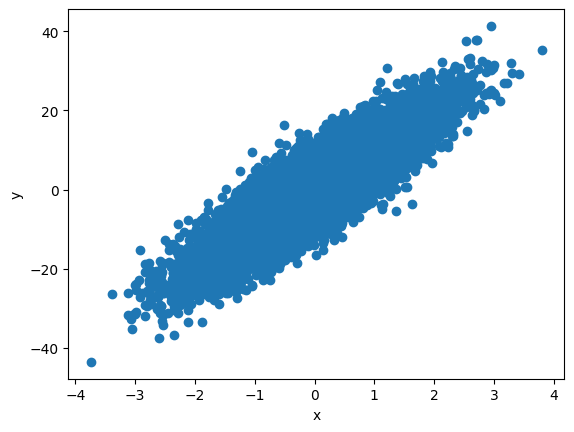

In [8]:
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**What you should see: a thick diagonal band.**

The band goes up to the right, so the invented slope was positive. The band has
*width* — that width is the `noise=5` you asked for. With `noise=0` it would be
a perfectly thin line.

One practical point. You are drawing **10,000 points** at the default marker
size. They pile on top of each other, so the middle is a solid blob and you
cannot tell where the data is dense. Two fixes: shrink the marker (`s`) and
make each point see-through (`alpha`).

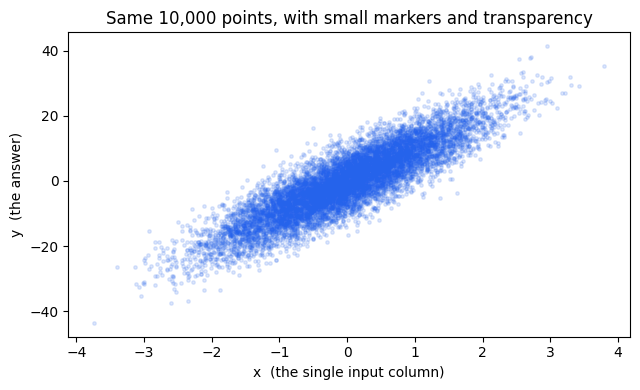

In [9]:
plt.figure(figsize=(6.5, 4))
plt.scatter(x, y, s=6, alpha=0.15, color="#2563eb")
plt.xlabel("x  (the single input column)")
plt.ylabel("y  (the answer)")
plt.title("Same 10,000 points, with small markers and transparency")
plt.tight_layout()
plt.show()

### The `noise` knob, drawn

`noise` is the standard deviation of the random number added to every `y`.
It is the only thing standing between your data and a perfect straight line.

Turn it up and the relationship gets harder to see — which is exactly how you
test whether a model is finding a real pattern or fooling itself.

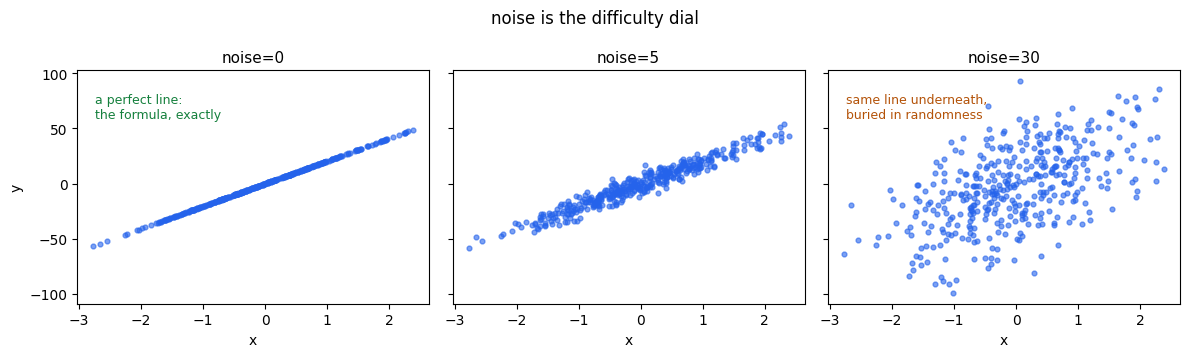

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)

for ax, level in zip(axes, [0, 5, 30]):
    nx, ny = make_regression(n_samples=400, n_features=1, noise=level, random_state=0)
    ax.scatter(nx, ny, s=12, alpha=0.6, color="#2563eb")
    ax.set_title(f"noise={level}", fontsize=11)
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
axes[0].text(0.05, 0.9, "a perfect line:\nthe formula, exactly", transform=axes[0].transAxes,
             fontsize=9, va="top", color="#15803d")
axes[2].text(0.05, 0.9, "same line underneath,\nburied in randomness", transform=axes[2].transAxes,
             fontsize=9, va="top", color="#b45309")
fig.suptitle("noise is the difficulty dial", fontsize=12)
plt.tight_layout()
plt.show()

### `coef=True` — the answer key

This is the reason synthetic data exists. Ask for the coefficient and
scikit-learn tells you the **true slope** it used. Later, when you fit a
`LinearRegression`, you can compare `model.coef_` against this number and see
how close the model got.

`bias` is the intercept — where the line crosses `x = 0`. Below it is set to
`50`, so the whole cloud lifts by 50.

true slope (coef) : 62.8898
true intercept    : 50   (this is the `bias` argument)
so the hidden formula is:  y = 62.89 * x + 50 + noise(sd=5)


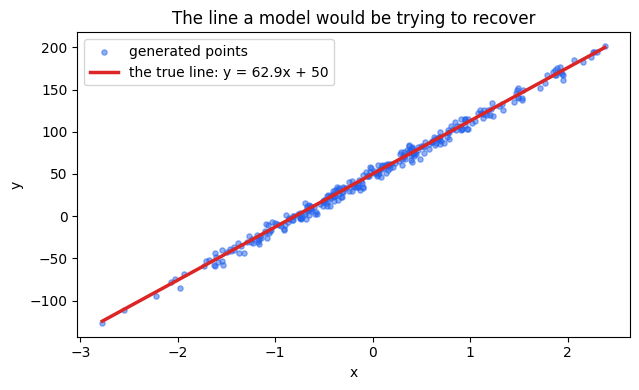

In [11]:
cx, cy, true_slope = make_regression(n_samples=300, n_features=1, noise=5,
                                     bias=50, coef=True, random_state=0)

slope = float(np.ravel(true_slope)[0])
print(f"true slope (coef) : {slope:.4f}")
print(f"true intercept    : 50   (this is the `bias` argument)")
print(f"so the hidden formula is:  y = {slope:.2f} * x + 50 + noise(sd=5)")

line_x = np.linspace(cx.min(), cx.max(), 2)
plt.figure(figsize=(6.5, 4))
plt.scatter(cx, cy, s=14, alpha=0.5, color="#2563eb", label="generated points")
plt.plot(line_x, slope * line_x + 50, color="#dc2626", linewidth=2.5,
         label=f"the true line: y = {slope:.1f}x + 50")
plt.xlabel("x"); plt.ylabel("y")
plt.title("The line a model would be trying to recover")
plt.legend()
plt.tight_layout()
plt.show()

### More than one column: where the scatter plot stops working

Your call used `n_features=1`, so one scatter plot showed everything. That is
rare. Real data has many columns, and a 2-D chart can only ever show one of
them against `y` at a time.

`n_informative` decides how many columns matter. Below: **3 columns, only 1 of
them informative**. Two of the three panels are pure noise — and because
`shuffle=True` is the default, you do not get to know in advance which panel
that will be.

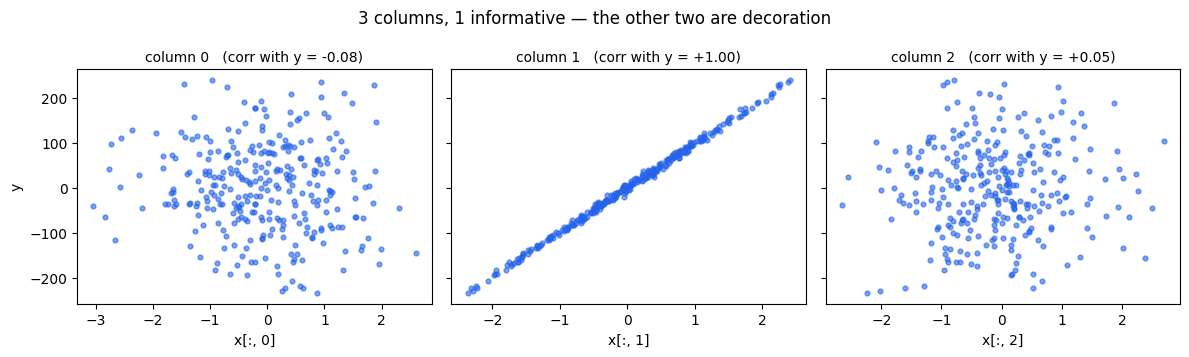

Only one column has a strong correlation. That is the informative one.
The other two exist so that feature-selection code has something to throw away.


In [12]:
mx, my = make_regression(n_samples=300, n_features=3, n_informative=1,
                         noise=5, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for j, ax in enumerate(axes):
    correlation = np.corrcoef(mx[:, j], my)[0, 1]
    ax.scatter(mx[:, j], my, s=12, alpha=0.6, color="#2563eb")
    ax.set_title(f"column {j}   (corr with y = {correlation:+.2f})", fontsize=10)
    ax.set_xlabel(f"x[:, {j}]")

axes[0].set_ylabel("y")
fig.suptitle("3 columns, 1 informative — the other two are decoration", fontsize=12)
plt.tight_layout()
plt.show()

print("Only one column has a strong correlation. That is the informative one.")
print("The other two exist so that feature-selection code has something to throw away.")

## 3 — `make_classification`: groups instead of numbers

**Classification** means the answer is a **label**: fraud / not fraud,
spam / not spam, `0` / `1`. Not a quantity.

### How the data is actually built

This generator is more elaborate than the others, and knowing the recipe
explains every strange chart you will see below.

```text
 1. place one corner per cluster on the corners of a cube        <- n_clusters_per_class, class_sep
 2. sprinkle normal points around each corner                    <- n_samples
 3. those coordinates become the INFORMATIVE columns             <- n_informative
 4. add columns that are random mixes of the informative ones    <- n_redundant
 5. add exact copies of some columns                             <- n_repeated
 6. fill any remaining columns with pure noise                   <- the leftovers: "useless"
 7. flip a few labels at random, on purpose                      <- flip_y
 8. shuffle the rows AND the column order                        <- shuffle
```

So a column can be one of four things:

| Column type | What it holds | Should a model use it? |
|---|---|---|
| **informative** | a real coordinate of the cluster | yes — this is the signal |
| **redundant** | a linear mix of the informative ones | it adds no new information |
| **repeated** | an exact copy of another column | no |
| **useless** | pure noise, unrelated to `y` | no — and a weak model will still try |

That last group is the point. Real datasets are full of columns that look
important and are not. This generator lets you create that situation on demand
and check whether your feature selection throws the right ones away.

In [13]:
from sklearn.datasets import make_classification

### Every parameter

| Parameter | Default | What it does |
|---|---|---|
| `n_samples` | `100` | how many rows |
| `n_features` | `20` | how many columns in total |
| `n_informative` | `2` | how many carry real signal |
| `n_redundant` | `2` | how many are linear mixes of the informative ones |
| `n_repeated` | `0` | how many are exact copies |
| `n_classes` | `2` | how many labels |
| `n_clusters_per_class` | `2` | how many separate blobs each class is split into |
| `weights` | `None` | class balance, e.g. `[0.9, 0.1]` for an imbalanced problem |
| `flip_y` | `0.01` | fraction of labels flipped at random — deliberate mislabelling |
| `class_sep` | `1.0` | how far apart the classes sit. Bigger = easier |
| `hypercube` | `True` | put the cluster centres on cube corners rather than a random shape |
| `shift` / `scale` | `0.0` / `1.0` | move and stretch the columns afterwards |
| `shuffle` | `True` | shuffle the rows **and the column order** |
| `random_state` | `None` | the seed |

**The rule that catches people:**
`n_informative + n_redundant + n_repeated ≤ n_features`.

Your call sets `n_features=5` and leaves the rest at their defaults, so:

```text
   5 columns = 2 informative + 2 redundant + 0 repeated + 1 useless
```

Two observations about your call, neither of them a bug:

1. **No `random_state`.** Every re-run of this cell produces a completely
   different dataset and a different picture. Fine while exploring; add a seed
   the moment you want to compare two runs.
2. **`flip_y=0.01` is still on.** About 1% of the labels are wrong on purpose.
   That is why you should not expect — or trust — a perfect separation.

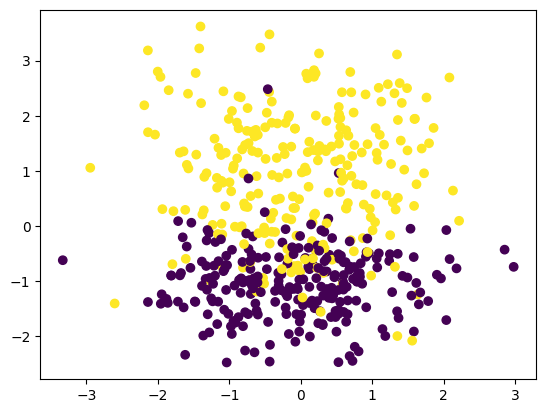

In [14]:
x,y = make_classification(n_classes=2,n_features=5,n_samples=500)
plt.scatter(x[:,0],x[:,1],c=y)

**Two things in that output.**

`plt.scatter(...)` returns the artist it drew, and Jupyter prints the last
expression of a cell. That is the `<matplotlib.collections.PathCollection ...>`
line above the chart. Add a semicolon (`plt.scatter(...);`) or call
`plt.show()` to hide it.

More importantly: **you plotted columns 0 and 1, but you do not know what
columns 0 and 1 are.** `shuffle=True` shuffled the column order, so the two
informative columns landed somewhere random among the five. If this chart looks
like a mess, that is the most likely reason — not a broken generator.

The section after next takes the shuffle off, so the roles become known.

### The two arrays for a classification problem

`x` is the same kind of table as before: 500 rows × 5 columns of floats.
`y` is different — it holds **only `0` and `1`**, one label per row.

In [15]:
x

array([[ 0.52964955, -1.52158144, -1.00449325, -1.04583869,  0.03813919],
       [ 0.2552979 ,  3.12979344,  0.28657108, -0.25320077, -0.06708268],
       [ 0.15671694, -0.27410954, -0.89920602, -1.15883029,  0.01145847],
       ...,
       [ 1.57971092, -0.56393124, -0.80536408, -0.97274023,  0.01690147],
       [-0.60155913, -0.91530415,  0.66398355,  1.08438733,  0.01484177],
       [ 1.59016142,  1.94048849, -0.28352238, -0.78010965, -0.03864574]],
      shape=(500, 5))

In [16]:
y

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,

In [17]:
print("y contains only:", np.unique(y), "  counts:", np.bincount(y))
print("x shape:", x.shape, "  y shape:", y.shape)
print()

# Why random_state matters: two calls with no seed, then two with a seed.
a, _ = make_classification(n_classes=2, n_features=5, n_samples=5)
b, _ = make_classification(n_classes=2, n_features=5, n_samples=5)
print("no seed  , run 1, first row:", a[0].round(2))
print("no seed  , run 2, first row:", b[0].round(2), " <- different data")

c, _ = make_classification(n_classes=2, n_features=5, n_samples=5, random_state=7)
d, _ = make_classification(n_classes=2, n_features=5, n_samples=5, random_state=7)
print("seed = 7 , run 1, first row:", c[0].round(2))
print("seed = 7 , run 2, first row:", d[0].round(2), " <- identical, every time")

y contains only: [0 1]   counts: [249 251]
x shape: (500, 5)   y shape: (500,)

no seed  , run 1, first row: [ 1.8  -0.61 -0.31 -2.84 -1.21]
no seed  , run 2, first row: [-0.89 -0.09 -1.04 -1.27 -1.55]  <- different data
seed = 7 , run 1, first row: [-0.55  1.05 -0.82  0.02  1.07]
seed = 7 , run 2, first row: [-0.55  1.05 -0.82  0.02  1.07]  <- identical, every time


### The column anatomy, made visible

Set `shuffle=False` and the column order becomes **fixed and documented**:

```text
   [ informative | redundant | repeated | useless ]
        0    1        2   3       —          4
```

Now the roles are known, so the same four scatter plots you drew by hand later
in this notebook can be read properly. `n_clusters_per_class=1` is used here so
each class is a single blob and the picture stays clean.

columns in the table            : 5
independent directions (rank)   : 3
-> the 2 redundant columns are mixes of the informative ones. They add nothing.

column 0  informative   distance between class means = +0.04
column 1  informative   distance between class means = -2.00
column 2  redundant     distance between class means = +1.05
column 3  redundant     distance between class means = -0.49
column 4  useless       distance between class means = +0.09


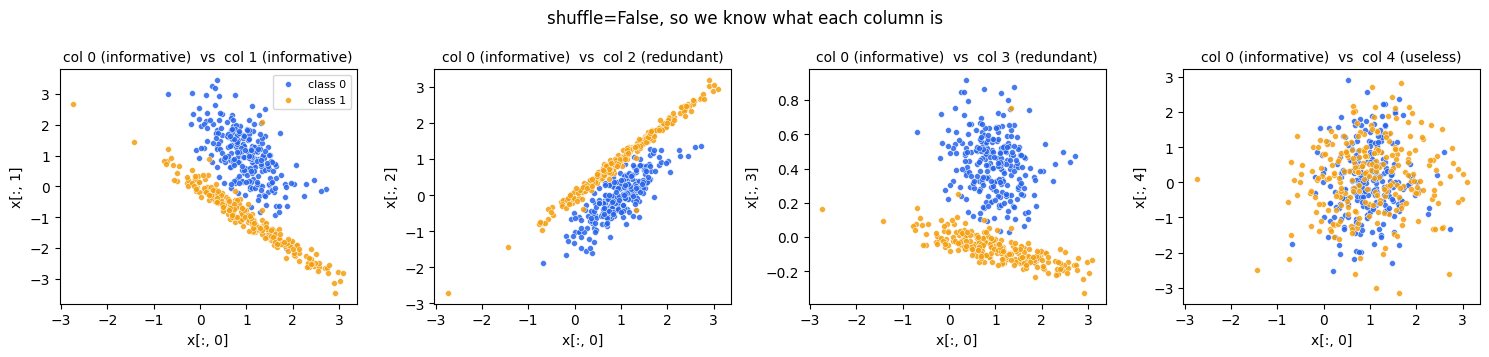

In [18]:
demo_x, demo_y = make_classification(n_samples=500, n_features=5, n_classes=2,
                                     n_informative=2, n_redundant=2, n_repeated=0,
                                     n_clusters_per_class=1,
                                     shuffle=False, random_state=1)

roles = ["informative", "informative", "redundant", "redundant", "useless"]

# 5 columns, but how many independent directions are really in there?
print("columns in the table            :", demo_x.shape[1])
print("independent directions (rank)   :", np.linalg.matrix_rank(demo_x))
print("-> the 2 redundant columns are mixes of the informative ones. They add nothing.")
print()
for j, role in enumerate(roles):
    gap = demo_x[demo_y == 1, j].mean() - demo_x[demo_y == 0, j].mean()
    print(f"column {j}  {role:<12}  distance between class means = {gap:+.2f}")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, other in zip(axes, [1, 2, 3, 4]):
    scatter_classes(ax, demo_x, demo_y, cols=(0, other),
                    title=f"col 0 ({roles[0]})  vs  col {other} ({roles[other]})")
    ax.set_xlabel("x[:, 0]"); ax.set_ylabel(f"x[:, {other}]")

axes[0].legend(fontsize=8, loc="best")
fig.suptitle("shuffle=False, so we know what each column is", fontsize=12)
plt.tight_layout()
plt.show()

**How to read those four panels.**

- **col 0 vs col 1** — informative against informative. Two clear groups, and
  almost all of the separation is **vertical**. The printed table says why: the
  class centres are `2.00` apart on column 1 and only `0.04` apart on column 0.
- **So "informative" does not mean "separates on its own."** It means the column
  was used to build the space. Column 0 looks useless in a single scatter and is
  still part of the real structure. This is why you look at *pairs*, and why a
  model looks at all the columns at once instead of filtering them one by one.
- **col 0 vs col 2** and **col 0 vs col 3** — informative against redundant.
  These separate too, and the points sit in a **tilted band**. That band is the
  visual signature of a linear dependency: the redundant column is a mix of
  columns 0 and 1, so it inherits their separation while adding nothing new.
- **col 0 vs col 4** — informative against useless. One round, mixed cloud. No
  straight line at any angle helps, because neither axis carries class signal
  by itself.

**Engineering view.** A redundant column is a derived field — like storing
`total_price` next to `unit_price` and `quantity`. It is not wrong, but it is
not new information, and models that assume independent inputs (naive Bayes,
plain linear regression) get unstable when you feed them several of these.

### The difficulty knobs

Four parameters change how hard the problem is. Each panel below changes
exactly one of them, so you can see what it costs.

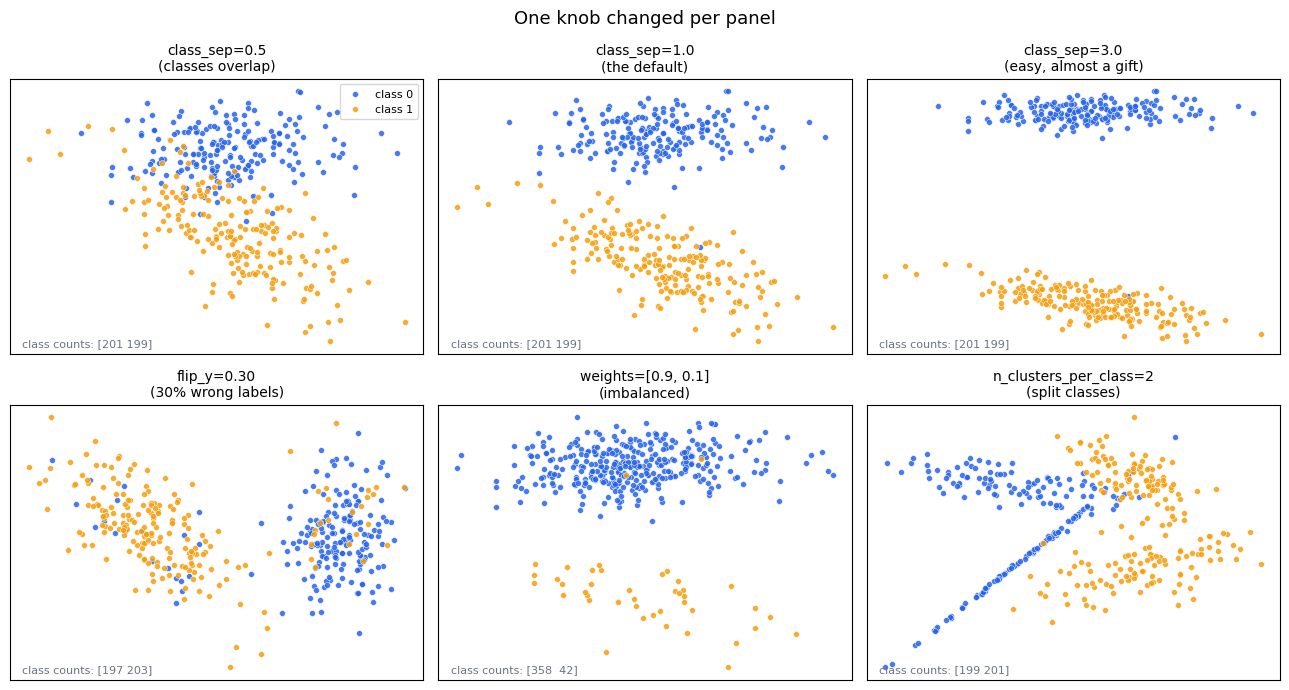

In [19]:
settings = [
    ("class_sep=0.5\n(classes overlap)",      dict(class_sep=0.5)),
    ("class_sep=1.0\n(the default)",          dict(class_sep=1.0)),
    ("class_sep=3.0\n(easy, almost a gift)",  dict(class_sep=3.0)),
    ("flip_y=0.30\n(30% wrong labels)",       dict(flip_y=0.30)),
    ("weights=[0.9, 0.1]\n(imbalanced)",      dict(weights=[0.9, 0.1])),
    ("n_clusters_per_class=2\n(split classes)", dict(n_clusters_per_class=2)),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (title, extra) in zip(axes.ravel(), settings):
    options = dict(n_samples=400, n_features=2, n_informative=2, n_redundant=0,
                   n_clusters_per_class=1, random_state=3)
    options.update(extra)
    kx, ky = make_classification(**options)
    scatter_classes(ax, kx, ky, title=title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.03, 0.03, f"class counts: {np.bincount(ky)}", transform=ax.transAxes,
            fontsize=8, color="#6b7280")

axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle("One knob changed per panel", fontsize=13)
plt.tight_layout()
plt.show()

**What each knob is for.**

| Knob | Real situation it imitates |
|---|---|
| `class_sep` | how distinguishable the two groups genuinely are. Low values are the honest case — fraud looks a lot like normal spending |
| `flip_y` | labelling errors. Someone ticked the wrong box in the source system |
| `weights` | class imbalance. 1 fraud in 1,000 transactions. Accuracy becomes a useless metric here — that is the lesson this knob exists to teach |
| `n_clusters_per_class` | one label, several different causes. "Churn" from price and "churn" from bad support are two separate blobs wearing the same label |

The last one explains your own charts earlier: the default is **2**, so each
class is two separate patches. A model that assumes one blob per class will
struggle, and the picture looks messier than a beginner expects.

## 4 — `make_blobs`: round groups, for clustering

`make_blobs` drops a few centre points into space and scatters normal noise
around each one. That is the entire algorithm.

The difference from `make_classification` is what `y` **means**:

```text
   make_classification   y = the true label      (supervised: you are given it)
   make_blobs            y = which blob it came from
                             (unsupervised: you normally THROW IT AWAY and
                              ask the algorithm to rediscover the groups)
```

So `make_blobs` is the test rig for **KMeans**, **DBSCAN**, and hierarchical
clustering. You keep `y` only to check the algorithm's answer afterwards.

### Every parameter

| Parameter | Default | What it does |
|---|---|---|
| `n_samples` | `100` | total rows — or a **list**, one count per centre, e.g. `[300, 100, 50]` |
| `n_features` | `2` | how many columns. `2` because you want to draw it |
| `centers` | `None` | a number of blobs, **or** an array of exact coordinates |
| `cluster_std` | `1.0` | how spread out each blob is. One number, or one per blob |
| `center_box` | `(-10, 10)` | the square the random centres are drawn from |
| `shuffle` | `True` | shuffle the rows |
| `random_state` | `None` | the seed |
| `return_centers` | `False` | `True` also returns the true centre coordinates |

There is no `n_informative`, no `n_redundant`, no `flip_y`. Every column of
`make_blobs` is real. That is deliberate: clustering is hard enough without
decoy columns.

In [20]:
from sklearn.datasets import make_blobs

Your call:

```python
x, y = make_blobs(n_samples=500, centers=3, n_features=2, random_state=0)
```

*"500 rows, 3 groups, 2 columns so I can plot it, and the same result every
time."* The centres themselves are chosen at random inside `center_box`, which
is why the seed matters here too.

In [21]:
x, y = make_blobs(n_samples=500, centers=3, n_features=2,random_state=0)

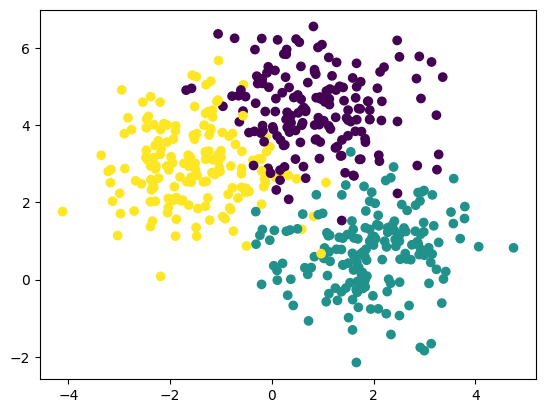

In [22]:
plt.scatter(x[:,0],x[:,1],c=y)

**Three clean, round clouds.** They are round because the noise added around
each centre is the same in every direction (`cluster_std` is one number).

Two parameters change everything about this picture: `cluster_std` decides
whether the groups stay apart, and `centers` lets you place them by hand
instead of letting the seed choose.

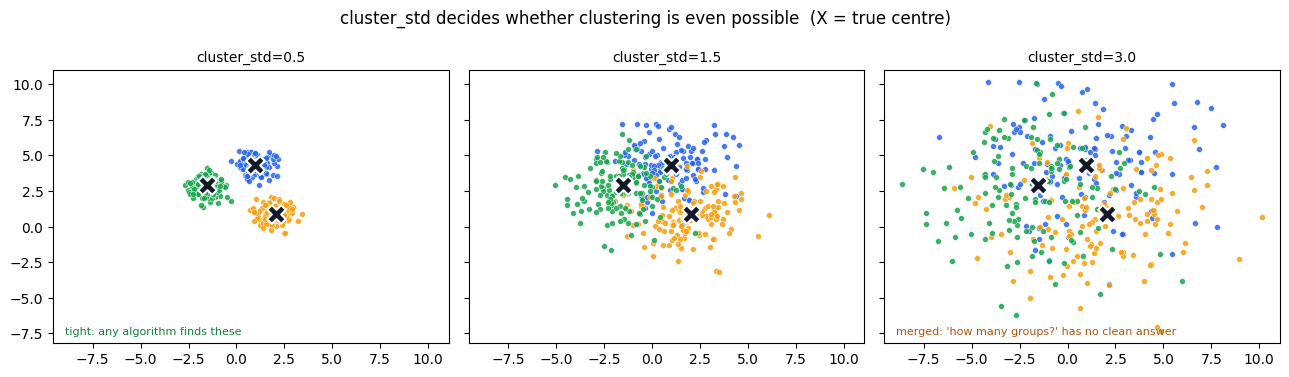

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)

for ax, spread in zip(axes, [0.5, 1.5, 3.0]):
    bx, by, centres = make_blobs(n_samples=400, centers=3, n_features=2,
                                 cluster_std=spread, random_state=0,
                                 return_centers=True)
    scatter_classes(ax, bx, by, title=f"cluster_std={spread}")
    ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=180, c="#111827",
               edgecolor="white", linewidth=1.5, zorder=5)

axes[0].text(0.03, 0.03, "tight: any algorithm finds these", transform=axes[0].transAxes,
             fontsize=8, color="#15803d")
axes[2].text(0.03, 0.03, "merged: 'how many groups?' has no clean answer",
             transform=axes[2].transAxes, fontsize=8, color="#b45309")
fig.suptitle("cluster_std decides whether clustering is even possible  (X = true centre)", fontsize=12)
plt.tight_layout()
plt.show()

### Placing the centres yourself

`centers=3` lets the seed pick the locations. Passing coordinates instead makes
the dataset exactly reproducible **and** lets you build the awkward cases on
purpose — two blobs close together and one far away, or blobs of very different
sizes and densities. That is how you find out where KMeans goes wrong, since it
assumes round clusters of similar size.

rows per blob: [300 300  60]


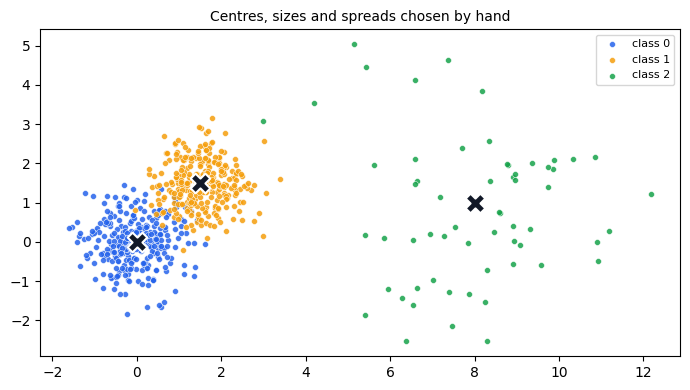

In [24]:
chosen_centres = np.array([[0.0, 0.0],
                           [1.5, 1.5],     # deliberately close to the first
                           [8.0, 1.0]])    # far away

hx, hy = make_blobs(n_samples=[300, 300, 60],       # different size per blob
                    centers=chosen_centres,
                    cluster_std=[0.6, 0.6, 1.8],    # different spread per blob
                    random_state=0)

print("rows per blob:", np.bincount(hy))

fig, ax = plt.subplots(figsize=(7, 4))
scatter_classes(ax, hx, hy, title="Centres, sizes and spreads chosen by hand")
ax.scatter(chosen_centres[:, 0], chosen_centres[:, 1], marker="X", s=200,
           c="#111827", edgecolor="white", linewidth=1.5, zorder=5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5 — `make_circles`: when a straight line cannot work

Everything so far could be separated, more or less, by drawing a straight line
across the picture. `make_circles` exists to break that.

One class is a ring. The other class is a smaller ring **inside** it. No
straight line can put one class on one side and the other class on the other —
you would need a circle, or a model that can bend.

### Every parameter

| Parameter | Default | What it does |
|---|---|---|
| `n_samples` | `100` | total rows, split evenly between the two rings — or `(outer, inner)` |
| `factor` | `0.8` | inner radius ÷ outer radius. Must be `0 ≤ factor < 1`. Small = a big gap |
| `noise` | `None` | standard deviation of Gaussian noise added to the **point positions** |
| `shuffle` | `True` | shuffle the rows |
| `random_state` | `None` | the seed |

⚠️ `noise` means something different here than in `make_regression`. There it
wobbled the answer `y`. Here it wobbles the **coordinates**, thickening each
ring into a fuzzy band.

Your call uses `noise=0.03`, which is a light dusting — the rings stay clearly
separate. The default `factor=0.8` puts the inner ring quite close to the outer
one.

In [25]:
from sklearn.datasets import make_circles
x, y = make_circles(n_samples=500,random_state=1,noise=0.03)

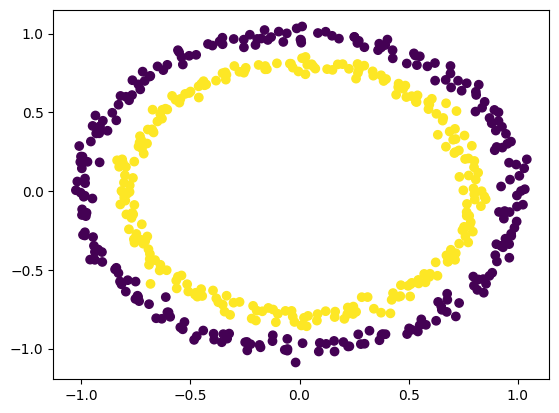

In [26]:
plt.scatter(x[:,0],x[:,1],c=y)

**A bullseye.** Two well-formed rings, one inside the other.

Now watch what `factor` and `noise` do. `factor` moves the inner ring outwards
until the two touch; `noise` blurs both until the gap disappears.

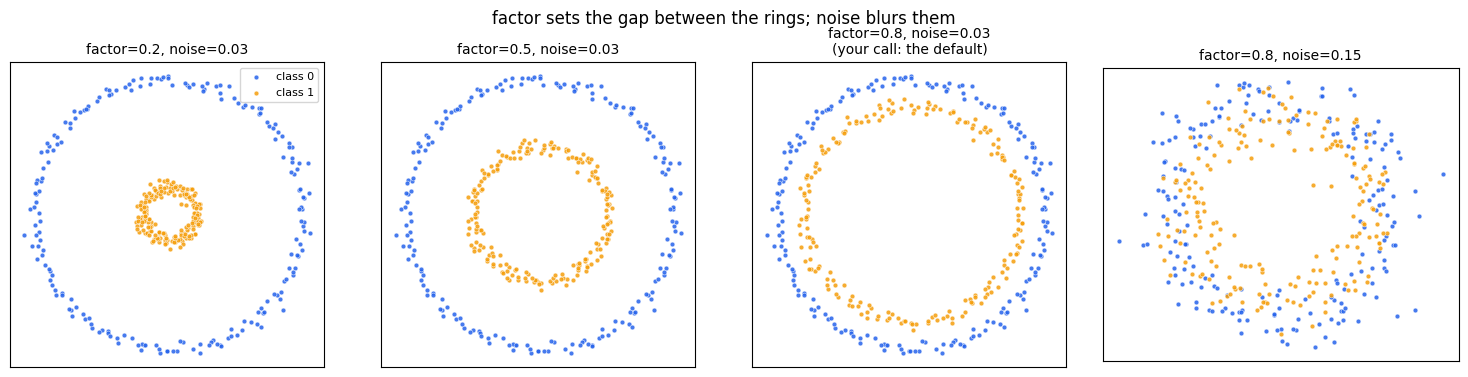

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

variants = [
    ("factor=0.2, noise=0.03", dict(factor=0.2, noise=0.03)),
    ("factor=0.5, noise=0.03", dict(factor=0.5, noise=0.03)),
    ("factor=0.8, noise=0.03\n(your call: the default)", dict(factor=0.8, noise=0.03)),
    ("factor=0.8, noise=0.15", dict(factor=0.8, noise=0.15)),
]

for ax, (title, extra) in zip(axes, variants):
    rx, ry = make_circles(n_samples=400, random_state=1, **extra)
    scatter_classes(ax, rx, ry, title=title, size=12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal")

axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("factor sets the gap between the rings; noise blurs them", fontsize=12)
plt.tight_layout()
plt.show()

## 6 — `make_moons`: two interlocking crescents

Same purpose as `make_circles`, different shape. Two half-circles hooked into
each other. Again, no straight line separates them.

Moons are the picture you see in almost every tutorial on decision boundaries,
because the correct boundary is an obvious S-curve that a human can draw by eye
and a linear model cannot produce.

### Every parameter

| Parameter | Default | What it does |
|---|---|---|
| `n_samples` | `100` | total rows — or `(upper, lower)` for an uneven split |
| `noise` | `None` | Gaussian noise added to the point positions |
| `shuffle` | `True` | shuffle the rows |
| `random_state` | `None` | the seed |

That is the whole list. There is no shape control — the crescents are always
the same crescents. Only `noise` changes the difficulty.

In [28]:
from sklearn.datasets import make_moons
x, y = make_moons(n_samples=500,random_state=10,noise=0.1)

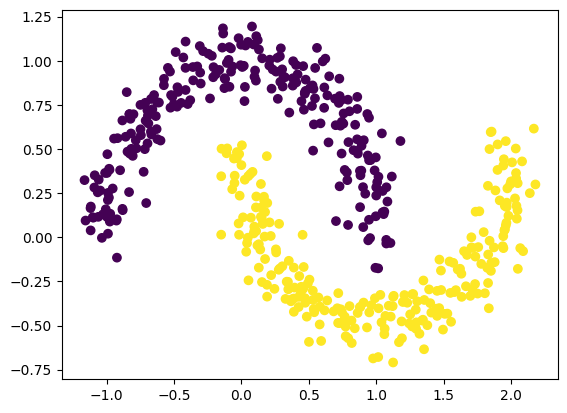

In [29]:
plt.scatter(x[:,0],x[:,1],c=y)

**Two crescents, slightly fuzzy.** `noise=0.1` is the usual choice: enough
blur to be realistic, not enough to destroy the shape.

Below, the noise is swept — and then the claim *"no straight line works"* is
actually tested rather than asserted.

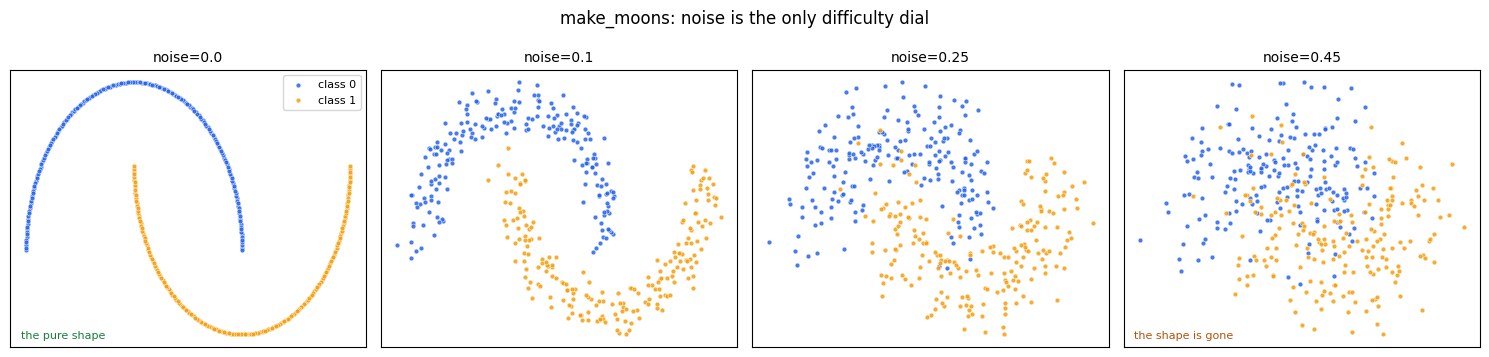

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))

for ax, level in zip(axes, [0.0, 0.1, 0.25, 0.45]):
    sx, sy = make_moons(n_samples=400, noise=level, random_state=10)
    scatter_classes(ax, sx, sy, title=f"noise={level}", size=12)
    ax.set_xticks([]); ax.set_yticks([])

axes[0].text(0.03, 0.03, "the pure shape", transform=axes[0].transAxes,
             fontsize=8, color="#15803d")
axes[3].text(0.03, 0.03, "the shape is gone", transform=axes[3].transAxes,
             fontsize=8, color="#b45309")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("make_moons: noise is the only difficulty dial", fontsize=12)
plt.tight_layout()
plt.show()

### Testing the claim: how good can a straight line be?

No model is fitted here — that comes later in the course. Instead this is brute
force: try **every** angle of straight line and **every** cut position, and
keep the best score. That is the ceiling any straight-line model could reach.

Compare the ceiling across three datasets and the point makes itself.

make_blobs (2 blobs)       best possible straight line: 98.0%
make_moons  (noise=0.1)    best possible straight line: 89.0%
make_circles (factor=0.5)  best possible straight line: 66.5%


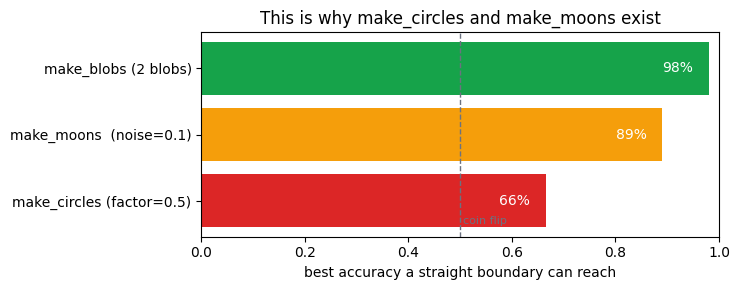

In [31]:
def best_straight_line_score(X, labels, angles=180, cuts=99):
    """Brute-force the best accuracy any straight boundary could reach."""
    best = 0.0
    for theta in np.linspace(0, np.pi, angles, endpoint=False):
        projected = X @ np.array([np.cos(theta), np.sin(theta)])
        for cut in np.quantile(projected, np.linspace(0.01, 0.99, cuts)):
            side = (projected > cut).astype(int)
            best = max(best, (side == labels).mean(), (1 - side == labels).mean())
    return best


tests = {
    "make_blobs (2 blobs)": make_blobs(n_samples=400, centers=2, n_features=2, random_state=0),
    "make_moons  (noise=0.1)": make_moons(n_samples=400, noise=0.1, random_state=10),
    "make_circles (factor=0.5)": make_circles(n_samples=400, noise=0.03, factor=0.5, random_state=1),
}

names, scores = [], []
for name, (tx, ty) in tests.items():
    score = best_straight_line_score(tx, ty)
    names.append(name); scores.append(score)
    print(f"{name:<26} best possible straight line: {score:.1%}")

fig, ax = plt.subplots(figsize=(7.5, 3))
bars = ax.barh(names, scores, color=["#16a34a", "#f59e0b", "#dc2626"])
ax.axvline(0.5, color="#6b7280", linestyle="--", linewidth=1)
ax.text(0.505, 2.35, "coin flip", fontsize=8, color="#6b7280")
ax.set_xlim(0, 1); ax.set_xlabel("best accuracy a straight boundary can reach")
for bar, score in zip(bars, scores):
    ax.text(score - 0.03, bar.get_y() + bar.get_height() / 2, f"{score:.0%}",
            va="center", ha="right", color="white", fontsize=10)
ax.invert_yaxis()
ax.set_title("This is why make_circles and make_moons exist")
plt.tight_layout()
plt.show()

**Read the bars.**

- **blobs — 98%.** A straight line gets essentially everything right. A linear
  model is the correct tool here, and anything fancier is wasted effort.
- **moons — 89%.** The best possible line still misses about one point in nine,
  and it can never do better. The crescents overlap along every direction you
  could cut.
- **circles — 66%.** Half of that is free: guessing one class already gets 50%.
  The inner ring is completely surrounded, so every straight cut leaves both
  classes on both sides. A linear model here is close to useless.

To solve the bottom two you need a model that can bend a boundary: KNN, a
decision tree, an SVM with an RBF kernel, or a small neural network. That is
the whole reason these two generators are in the library.

## 7 — Your own experiment: plotting column 0 against every other column

The next four cells are the most interesting thing in this notebook, because
you found a real problem by hand.

```python
x, y = make_classification(n_classes=2, n_features=5, n_samples=10, random_state=1)
plt.scatter(x[:, 0], x[:, 1], c=y)   # then 2, then 3, then 4
```

Two changes from your earlier call, both good ones:

- `random_state=1` — the dataset is now fixed, so the charts are comparable.
- `n_samples=10` — only 10 points, so you can see individual rows.

What you are doing is a **manual pair plot**: hold one column fixed and swap the
other, looking for the pair where the colours separate. This is exactly what
`seaborn.pairplot` automates, and it is a normal first move in EDA.

Watch how different the four charts look, and hold the question: *why does the
same column 0 look useful in one chart and useless in the next?*

⚠️ With only 10 points, do not over-read any of them. Ten points can look
separated by pure chance.

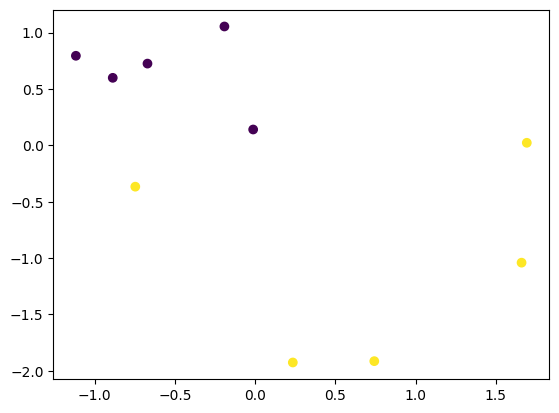

In [32]:
from sklearn.datasets import make_classification
x,y = make_classification(n_classes=2,n_features=5,n_samples=10,random_state=1)
plt.scatter(x[:,0],x[:,1],c=y)

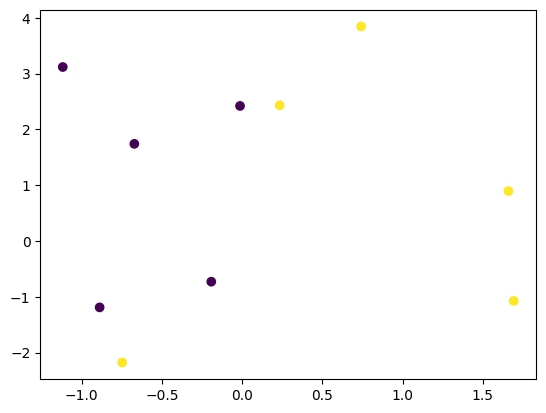

In [33]:
plt.scatter(x[:,0],x[:,2],c=y)

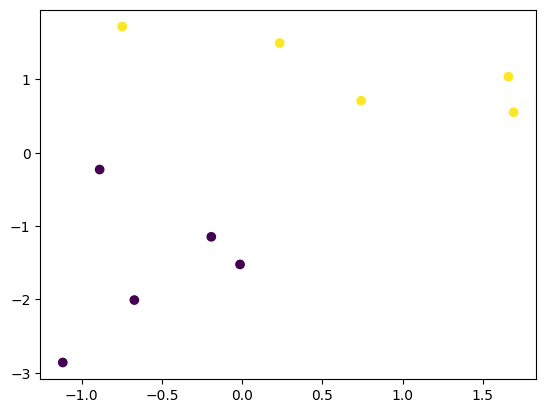

In [34]:
plt.scatter(x[:,0],x[:,3],c=y)

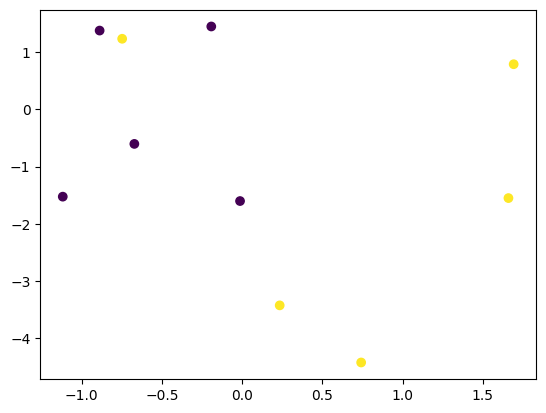

In [35]:
plt.scatter(x[:,0],x[:,4],c=y)

### Why the four charts disagree

`shuffle=True` is the default, so the column order was scrambled when the data
was made. Column 0 is not "the first feature" — it is whichever feature landed
in slot 0.

The roles can be recovered exactly. Generate the same seed twice, once with
`shuffle=False` (where the order is known: informative, redundant, useless) and
once as you called it. Shuffling reorders columns but does not change the
**values inside** a column, so sorting each column and matching gives the map.

your x[:, 0]  is  useless
your x[:, 1]  is  redundant
your x[:, 2]  is  redundant
your x[:, 3]  is  informative
your x[:, 4]  is  informative

so the four charts you drew were really:
  x[:, 0] vs x[:, 1]   ->   useless  vs  redundant
  x[:, 0] vs x[:, 2]   ->   useless  vs  redundant
  x[:, 0] vs x[:, 3]   ->   useless  vs  informative
  x[:, 0] vs x[:, 4]   ->   useless  vs  informative


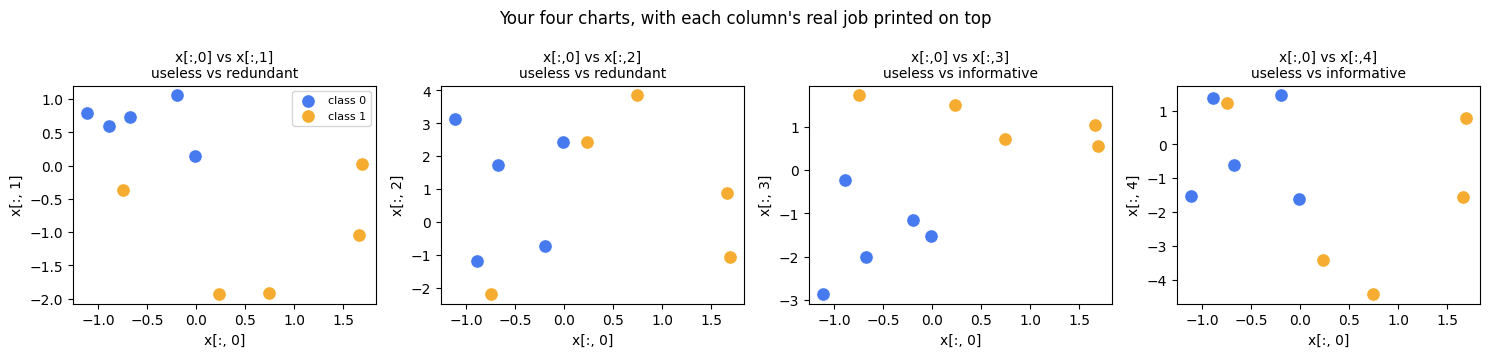

In [36]:
def column_roles(**call):
    # Work out what each column of a make_classification call really is.
    # Trick: generate the same seed twice - once with shuffle=False, where the
    # column order is documented, and once as called. Shuffling moves columns
    # around but never changes the values inside one, so sorting each column
    # and matching the two sets recovers the mapping exactly.
    shuffled, _ = make_classification(**call)
    ordered, _ = make_classification(**call, shuffle=False)
    # documented order for 5 columns with the default 2 informative + 2 redundant:
    known = ["informative", "informative", "redundant", "redundant", "useless"]
    roles = {}
    for j in range(shuffled.shape[1]):
        for k in range(ordered.shape[1]):
            if np.allclose(np.sort(shuffled[:, j]), np.sort(ordered[:, k])):
                roles[j] = known[k]
                break
    return roles


call = dict(n_classes=2, n_features=5, n_samples=10, random_state=1)
learner_x, learner_y = make_classification(**call)      # exactly your cell
column_role = column_roles(**call)

for j in range(5):
    print(f"your x[:, {j}]  is  {column_role[j]}")

print()
print("so the four charts you drew were really:")
for other in [1, 2, 3, 4]:
    print(f"  x[:, 0] vs x[:, {other}]   ->   {column_role[0]}  vs  {column_role[other]}")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, other in zip(axes, [1, 2, 3, 4]):
    scatter_classes(ax, learner_x, learner_y, cols=(0, other), size=90,
                    title=f"x[:,0] vs x[:,{other}]\n{column_role[0]} vs {column_role[other]}")
    ax.set_xlabel("x[:, 0]"); ax.set_ylabel(f"x[:, {other}]")

axes[0].legend(fontsize=8)
fig.suptitle("Your four charts, with each column's real job printed on top", fontsize=12)
plt.tight_layout()
plt.show()

**The result for this seed:**

```text
   x[:, 0]  ->  useless      (pure noise, nothing to do with y)
   x[:, 1]  ->  redundant
   x[:, 2]  ->  redundant
   x[:, 3]  ->  informative
   x[:, 4]  ->  informative
```

So every chart you drew had a **pure noise column on the horizontal axis**.

Now look at those four panels again, carefully. In **all four** the blue points
sit on the left and the orange points on the right — a split along column 0,
the column we just proved is noise.

**That split is a coincidence, and it is the most valuable thing in this
notebook.** With `n_samples=10` there are five points per class. Five random
values landing to the left of five other random values is not a rare event. Ten
points can be made to look like almost any pattern.

The cell below repeats the identical call with 500 rows instead of 10. The
useless column's fake separation disappears, and the two informative columns
show the structure that was there all along.

**The general lesson, and it is not a synthetic-data lesson.** Column position
tells you nothing about a column's value, and a small sample tells you nothing
about whether a pattern is real. You find both out by testing, not by looking.

The two printed percentages make the same point without any eyeballing: a pair
containing the useless column tops out near a coin flip, while the pair of
informative columns is separable by a straight line about nine times out of ten.

**Engineering view.** It is the same reason you do not index into a result set
by column number. `row.get(3)` compiles and runs; `row.get("customer_id")`
tells the truth. NumPy has no column names, which is precisely why people load
data through Pandas, keep the names as long as possible, and only drop to raw
arrays at the last moment.

with 500 rows the roles land as: {0: 'informative', 1: 'redundant', 2: 'redundant', 3: 'useless', 4: 'informative'}


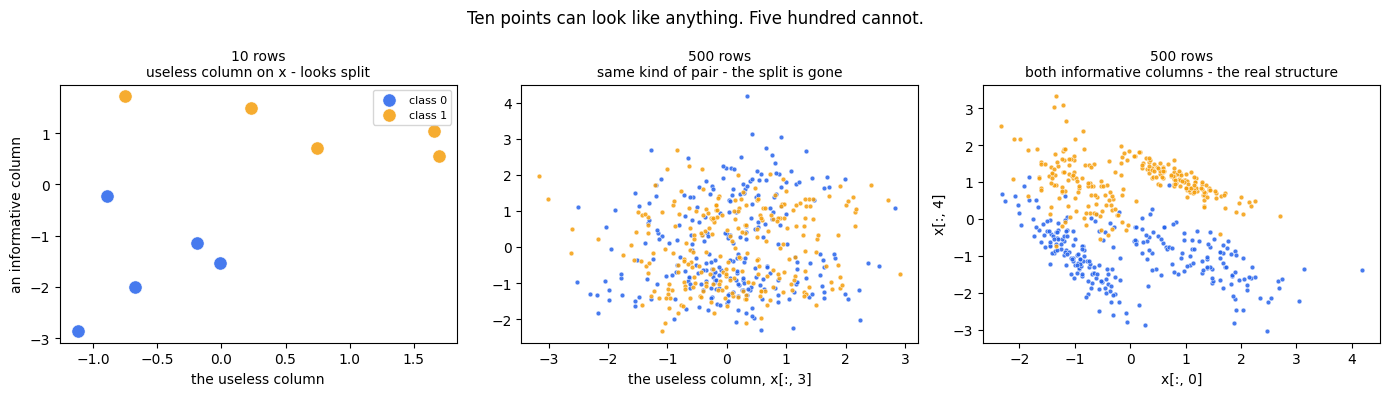

useless + informative  ->  best straight line: 57.2%


both informative       ->  best straight line: 94.0%


In [37]:
big_call = dict(n_classes=2, n_features=5, n_samples=500, random_state=1)
big_x, big_y = make_classification(**big_call)
big_role = column_roles(**big_call)
print("with 500 rows the roles land as:", big_role)

useless_col      = next(j for j, r in big_role.items() if r == "useless")
informative_cols = [j for j, r in big_role.items() if r == "informative"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

scatter_classes(axes[0], learner_x, learner_y, cols=(0, 3), size=90,
                title="10 rows\nuseless column on x - looks split")
axes[0].set_xlabel("the useless column")
axes[0].set_ylabel("an informative column")

scatter_classes(axes[1], big_x, big_y, cols=(useless_col, informative_cols[0]), size=12,
                title="500 rows\nsame kind of pair - the split is gone")
axes[1].set_xlabel(f"the useless column, x[:, {useless_col}]")

scatter_classes(axes[2], big_x, big_y, cols=tuple(informative_cols), size=12,
                title="500 rows\nboth informative columns - the real structure")
axes[2].set_xlabel(f"x[:, {informative_cols[0]}]")
axes[2].set_ylabel(f"x[:, {informative_cols[1]}]")

axes[0].legend(fontsize=8)
fig.suptitle("Ten points can look like anything. Five hundred cannot.", fontsize=12)
plt.tight_layout()
plt.show()

# the same brute-force straight line as before, now as a number
pair_useless = big_x[:, [useless_col, informative_cols[0]]]
pair_real    = big_x[:, informative_cols]
print(f"useless + informative  ->  best straight line: {best_straight_line_score(pair_useless, big_y):.1%}")
print(f"both informative       ->  best straight line: {best_straight_line_score(pair_real, big_y):.1%}")

## 8 — The last cell: read the error before you run it

```python
plt.scatter(x[:, 0], x[:, 5], c=y)
```

Before running: `x` has **5 columns**. Python counts from **0**. So the valid
column numbers are `0, 1, 2, 3, 4`. There is no `5`.

```text
     column number:    0     1     2     3     4
                    ┌─────┬─────┬─────┬─────┬─────┐
     x  =           │     │     │     │     │     │      x.shape -> (10, 5)
                    └─────┴─────┴─────┴─────┴─────┘
                                                   ↑
                                                  x[:, 5] points here — off the end
```

The cell below is **kept on purpose**. A failure you understand is worth more
than a cell you deleted.

In [38]:
plt.scatter(x[:,0],x[:,5],c=y)

IndexError: index 5 is out of bounds for axis 1 with size 5

### Reading the traceback

```text
IndexError: index 5 is out of bounds for axis 1 with size 5
             │                                │         │
             │                                │         └── that axis has 5 slots
             │                                └── axis 1 = columns (axis 0 = rows)
             └── the number you asked for
```

`size 5` and `index 5` in the same sentence is the classic off-by-one. Size 5
means the **last valid index is 4**.

**Two habits that prevent it.**

1. Check the shape before indexing: `x.shape` → `(10, 5)`.
2. Never hardcode a column count. Loop over `range(x.shape[1])` and the code
   adapts when you change `n_features`.

Here is your experiment written that way. It draws every column against
column 0 automatically, and it cannot run off the end.

the array has 10 rows and 5 columns
valid column indexes: 0 .. 4


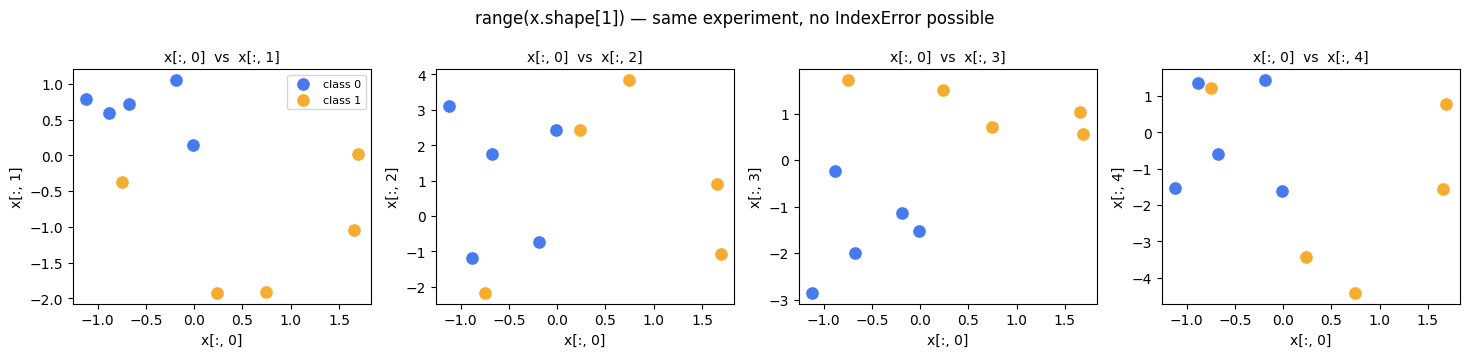

column 5 does not exist — there are only 5 columns (0..4)


In [39]:
rows, columns = learner_x.shape
print(f"the array has {rows} rows and {columns} columns")
print(f"valid column indexes: 0 .. {columns - 1}")

others = [j for j in range(columns) if j != 0]

fig, axes = plt.subplots(1, len(others), figsize=(3.7 * len(others), 3.6))
for ax, other in zip(axes, others):
    scatter_classes(ax, learner_x, learner_y, cols=(0, other), size=90,
                    title=f"x[:, 0]  vs  x[:, {other}]")
    ax.set_xlabel("x[:, 0]"); ax.set_ylabel(f"x[:, {other}]")

axes[0].legend(fontsize=8)
fig.suptitle("range(x.shape[1]) — same experiment, no IndexError possible", fontsize=12)
plt.tight_layout()
plt.show()

# The safe way to ask for a column that may not exist:
wanted = 5
if wanted < columns:
    print(learner_x[:, wanted])
else:
    print(f"column {wanted} does not exist — there are only {columns} columns (0..{columns - 1})")

## Which generator do I reach for?

| I want to practise… | Use | Because |
|---|---|---|
| linear regression, MSE, R², gradient descent | `make_regression` | the true slope is available with `coef=True`, so you can grade the model |
| logistic regression, trees, forests | `make_classification` | real labels, plus decoy columns and label noise |
| feature selection, PCA, multicollinearity | `make_classification` | `n_redundant` and the useless columns are the whole exercise |
| imbalanced-data metrics (precision, recall, ROC) | `make_classification` | `weights=[0.99, 0.01]` builds the problem in one line |
| KMeans, DBSCAN, the elbow method | `make_blobs` | round, separated groups with a known correct count |
| KNN, SVM kernels, neural networks, decision boundaries | `make_circles`, `make_moons` | linear models provably fail, so the improvement is visible |

## Common mistakes

| Mistake | What goes wrong |
|---|---|
| Leaving out `random_state` | Every run is a different dataset. You cannot tell whether your change helped or the data moved. Your first `make_classification` call has this. |
| Assuming column 0 is meaningful | `shuffle=True` scatters the informative columns. Verified above: your `x[:, 0]` was the useless one. |
| Forgetting the defaults | `make_regression` defaults to **100** columns, `make_classification` to **20**. Always set `n_features`. |
| `x[:, 5]` on a 5-column array | Indexes stop at 4. Use `range(x.shape[1])`. |
| Trusting a synthetic score | These datasets are clean, balanced and well behaved. A model scoring 0.99 here proves the code runs, not that the model is good. |

## Where this shows up in real work

- **Unit tests for an ML pipeline.** `make_classification(random_state=0)` in a
  test gives a deterministic dataset that fits in memory. The test asserts the
  pipeline runs, the shapes come out right, and the score does not fall below a
  floor. No dataset file in the repository.
- **Reproducing a bug.** "The model fails on imbalanced data" becomes a
  four-line reproduction with `weights=[0.99, 0.01]`, which you can attach to a
  ticket.
- **Load and latency testing a model service.** You need 100,000 rows of the
  right shape to hit an endpoint. You do not need real customer records — and
  using them would need a privacy review you can skip entirely.
- **Teaching and interviews.** Every decision-boundary picture you have seen
  was drawn on moons or circles.

## Interview view

1. **Why use synthetic data at all?** Because you know the ground truth. It is
   the only way to check whether a model recovered the pattern, rather than
   just scoring well.
2. **`make_blobs` vs `make_classification`?** Blobs are plain isotropic
   Gaussians and `y` is a cluster id — built for unsupervised work.
   `make_classification` adds redundant, repeated and useless columns, label
   noise (`flip_y`) and class imbalance (`weights`) — built for supervised work.
3. **Why do `make_circles` and `make_moons` exist?** To create data no linear
   boundary can separate, so kernel methods and non-linear models have
   something to prove themselves on.
4. **What does `n_redundant` simulate?** Multicollinearity — derived columns
   that carry no new information but destabilise linear models and inflate
   feature-importance scores.
5. **What does `noise` mean?** In `make_regression`, the spread added to the
   answer `y`. In `make_circles` and `make_moons`, the spread added to the
   point coordinates. Same word, different target.

## What is not covered here

No model has been fitted in this notebook. The natural next steps are to take
`make_regression` data into `LinearRegression` and compare `model.coef_` with
the `coef=True` answer key, and to take `make_moons` into both
`LogisticRegression` and `KNeighborsClassifier` to see the straight-line
ceiling from the bar chart above turn into two real scores.

## Key takeaway

**If you remember only one thing:** `make_*` gives you data whose answer you
already know — so always set `random_state`, always set `n_features`, and never
assume a column's position tells you what that column is for.